In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_data.csv")
df = df.drop([
    'Global_reactive_power','Voltage','Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3'], axis=1)
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)
df = df.sort_index()
df.columns

Index(['Global_active_power', 'hour', 'day', 'month', 'weekday', 'lag_1',
       'lag_2', 'lag_24', 'rolling_mean_3', 'rolling_mean_24'],
      dtype='object')

In [3]:
# Train-test split
train = df.loc[:'2009-12-31']
test = df.loc['2010-01-01':]

y_train = train['Global_active_power']
y_test = test['Global_active_power']

X_train = train.drop('Global_active_power', axis=1)
X_test = test.drop('Global_active_power', axis=1)
print("size of X_train:", X_train.shape, "size of y_train:", y_train.shape)
print("size of X_test:", X_test.shape, "size of y_test:", y_test.shape)

size of X_train: (26623, 9) size of y_train: (26623,)
size of X_test: (7918, 9) size of y_test: (7918,)


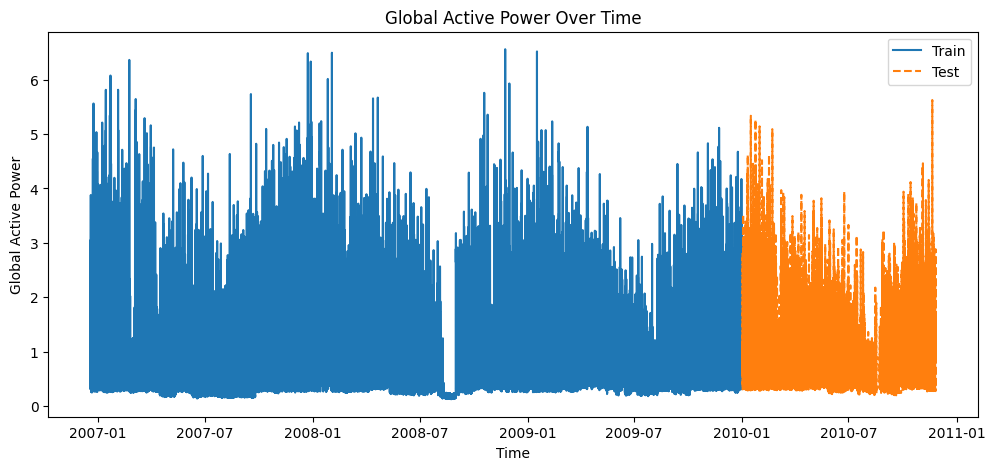

In [67]:
# plot
plt.figure(figsize=(12,5))
plt.plot(y_train.index, y_train, label='Train', linestyle='-')
plt.plot(y_test.index, y_test, label='Test', linestyle='--')
plt.title("Global Active Power Over Time")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.legend()
plt.show()

In [4]:
# Train a linear regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("MAE:", mae)
print("RMSE:", rmse)
residuals = y_test - preds

MAE: 0.38221754905621486
RMSE: 0.5377816326181188


In [6]:
# Naive forecast (previous value)
naive_preds = X_test['lag_1']

naive_mae = mean_absolute_error(y_test, naive_preds)
model_mae = mean_absolute_error(y_test, preds)

print("Naive MAE:", naive_mae)
print("Model MAE:", model_mae)

Naive MAE: 0.39491702745085766
Model MAE: 0.38221754905621486


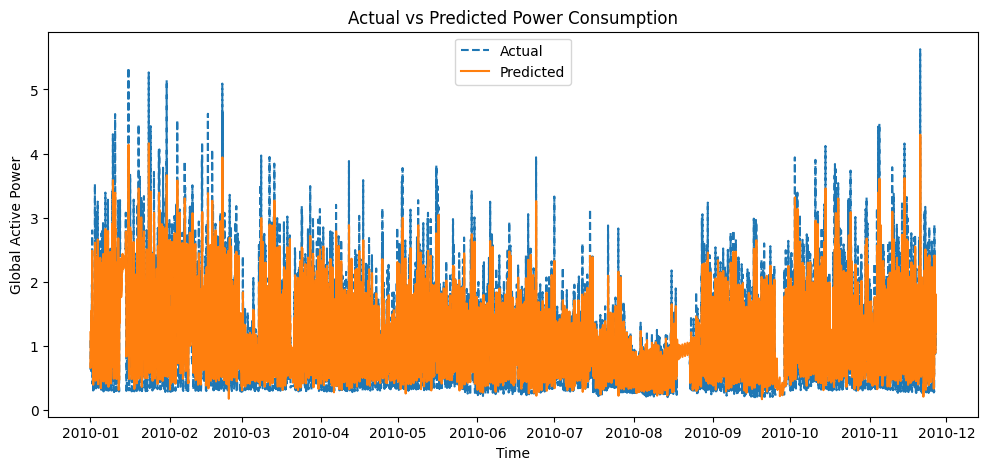

In [7]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label='Actual',linestyle='--')
plt.plot(y_test.index, preds, label='Predicted', linestyle='-')

plt.title("Actual vs Predicted Power Consumption")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.legend()

plt.show()

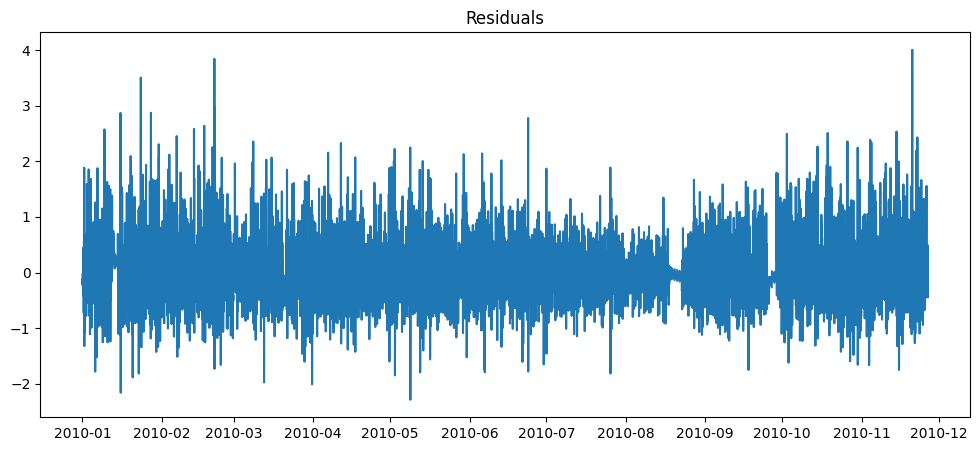

In [8]:
plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

In [9]:
print(residuals.describe())

count    7918.000000
mean       -0.006255
std         0.537779
min        -2.288005
25%        -0.277873
50%        -0.090660
75%         0.216481
max         4.006162
Name: Global_active_power, dtype: float64


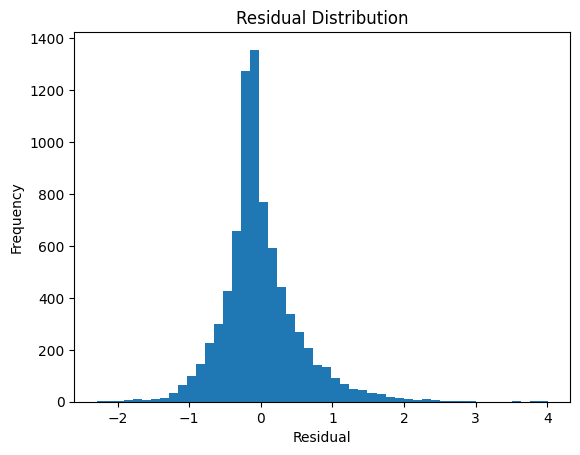

In [10]:
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

In [14]:
# percentile based anomalies
# 1. Find the residuals on the TRAIN set
train_preds = model.predict(X_train)
train_residuals = y_train - train_preds

upper_anomaly_threshold = train_residuals.quantile(0.99)
lower_anomaly_threshold = train_residuals.quantile(0.01)
test_anomalies = (residuals > upper_anomaly_threshold) | (residuals < lower_anomaly_threshold)
print("Total anomalies detected (percentile):", test_anomalies.sum())

Total anomalies detected (percentile): 81


count    7918.000000
mean       -0.006255
std         0.537779
min        -2.288005
25%        -0.277873
50%        -0.090660
75%         0.216481
max         4.006162
Name: Global_active_power, dtype: float64


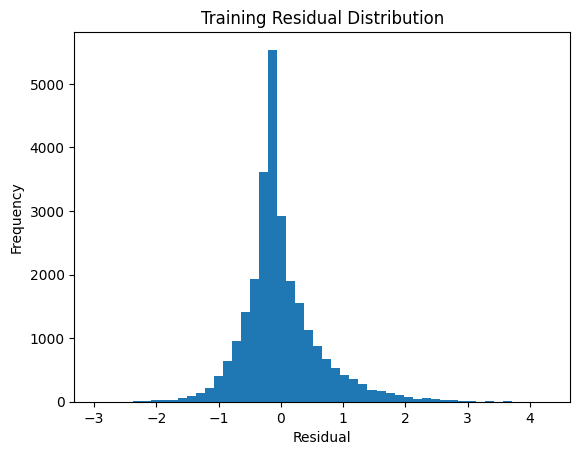

In [68]:
print(residuals.describe())
plt.hist(train_residuals, bins=50)
plt.title("Training Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

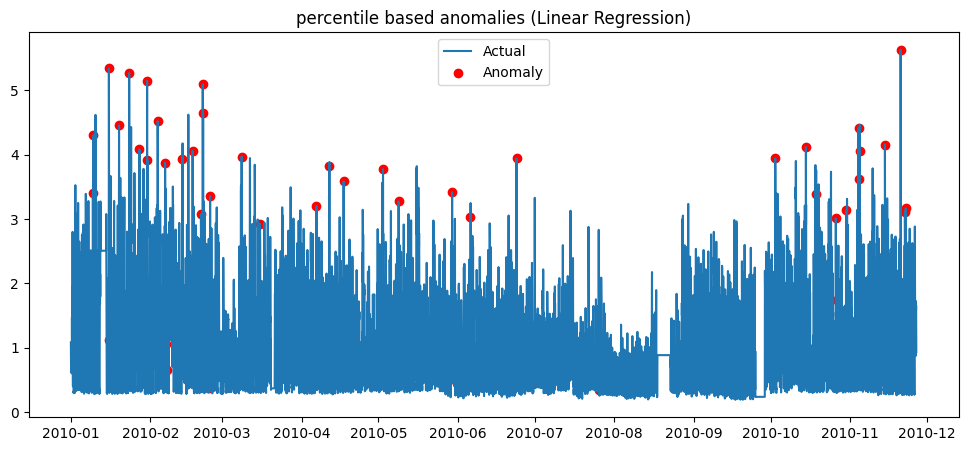

In [59]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual')

plt.scatter(
    y_test.index[test_anomalies],
    y_test[test_anomalies],
    color='red',
    label='Anomaly'
)
plt.title("percentile based anomalies (Linear Regression)")

plt.legend()
plt.show()

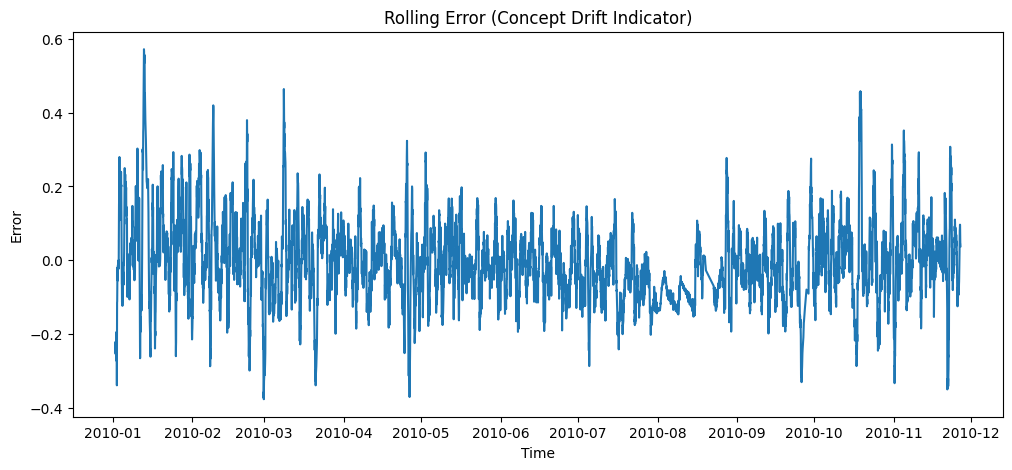

In [16]:
# Concept Drift
rolling_error = residuals.rolling(24).mean()

plt.figure(figsize=(12,5))
plt.plot(rolling_error)
plt.title("Rolling Error (Concept Drift Indicator)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()


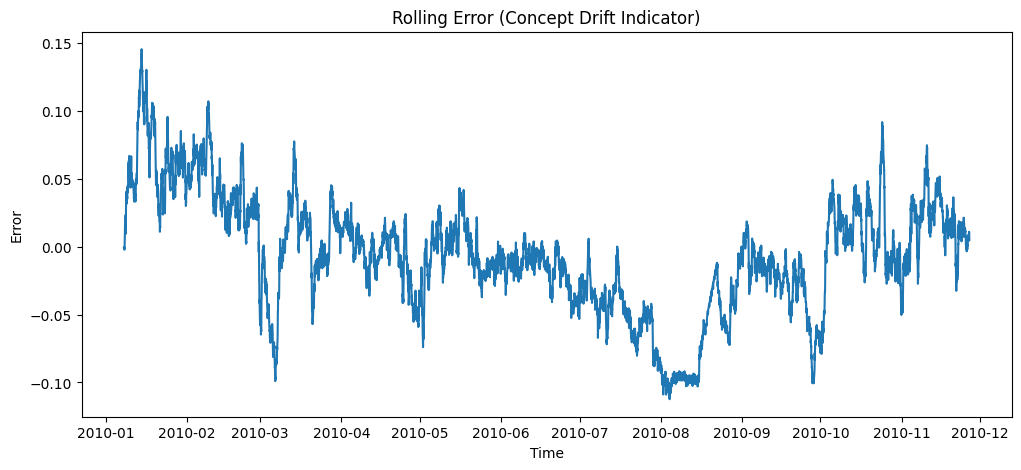

In [17]:
# Weekly smoothing
rolling_error = residuals.rolling(168).mean()
plt.figure(figsize=(12,5))
plt.plot(rolling_error)
plt.title("Rolling Error (Concept Drift Indicator)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

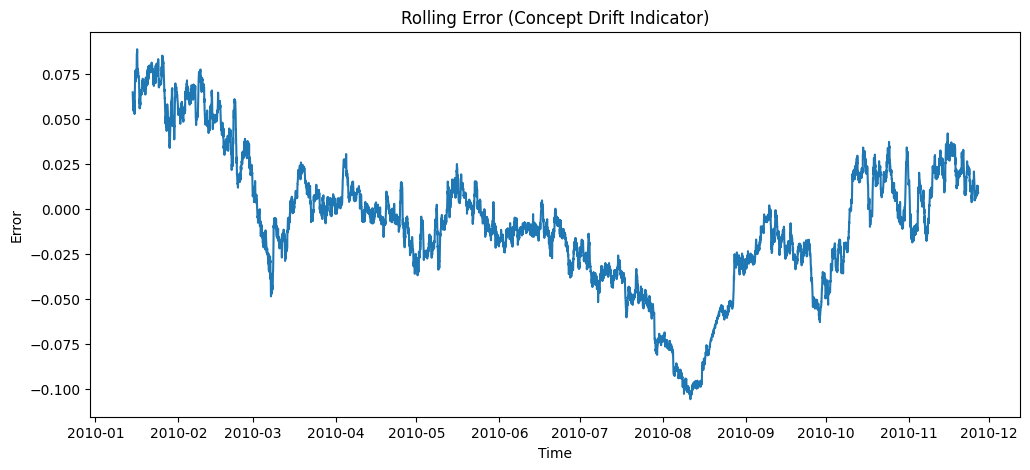

In [18]:
# 2 Weeks
rolling_error = residuals.rolling(336).mean()
plt.figure(figsize=(12,5))
plt.plot(rolling_error)
plt.title("Rolling Error (Concept Drift Indicator)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

In [ ]:
# Drift Monitoring
def drift_report(model, X_train, y_train, X_test, y_test):
    import pandas as pd
    from sklearn.metrics import mean_absolute_error
    
    # -------------------------------
    # Handle predictions (SKLEARN vs ARIMAX)
    # -------------------------------
    try:
        # Try sklearn-style
        train_preds = model.predict(X_train)
        test_preds = model.predict(X_test)
    except:
        # Fallback for ARIMAX (pmdarima)
        train_preds = model.predict_in_sample(X=X_train)
        test_preds = model.predict(n_periods=len(y_test), X=X_test)
    
    # Convert to Series (important for alignment)
    train_preds = pd.Series(train_preds, index=y_train.index)
    test_preds = pd.Series(test_preds, index=y_test.index)

    # -------------------------------
    # Performance Drift
    # -------------------------------
    train_mae = mean_absolute_error(y_train, train_preds)
    threshold = train_mae * 1.2  # 20% tolerance

    test_df = pd.DataFrame({
        'actual': y_test,
        'pred': test_preds
    })

    test_df['abs_error'] = abs(test_df['actual'] - test_df['pred'])
    test_df['rolling_mae'] = test_df['abs_error'].rolling(72).mean()
    test_df['rolling_mean_7d'] = test_df['actual'].rolling(168).mean()
    test_df['rolling_std_7d'] = test_df['actual'].rolling(168).std()
    test_df.dropna(inplace=True)

    print(f"Current 7-Day MAE: {test_df['rolling_mae'].iloc[-1]:.3f} (Threshold: {threshold:.3f})")
    
    if test_df['rolling_mae'].iloc[-1] > threshold:
        print(" Performance Drift Detected")
    else:
        print(" Performance Stable")

    # -------------------------------
    # Data Drift (Mean + Variance)
    # -------------------------------
    train_mean = y_train.mean()
    train_std = y_train.std()
    
    current_mean = test_df['rolling_mean_7d'].iloc[-1]
    current_std = test_df['rolling_std_7d'].iloc[-1]
    
    print(f"\nCurrent 7-Day Avg: {current_mean:.3f} kW (Train Avg: {train_mean:.3f})")
    
    threshold_upper = train_mean * 1.20 
    threshold_lower = train_mean * 0.80

    if current_mean > threshold_upper or current_mean < threshold_lower:
        print(" Data Drift Detected")
    else:
        print(" Data Stable")   
    
    std_ratio = current_std / train_std
    print(f"Std Ratio: {std_ratio:.2f}")

    if std_ratio > 1.3 or std_ratio < 0.7:
        print(" Variance Drift Detected")
    else:
        print(" Variance Stable")

In [20]:
# Before drift
drift_report(model, X_train, y_train, X_test, y_test)

Current 7-Day MAE: 0.360 (Threshold: 0.519)
 Performance Stable

Current 14-Day Avg: 1.145 kW (Train Avg: 1.097)
 Data Stable
Std Ratio: 0.92
 Variance Stable


In [21]:
# Drift simulation
# --- Base copy ---
y_test_base = y_test.copy()

# -------------------------------
# 1. Gradual Drift (MAIN)
# -------------------------------
y_gradual = y_test_base.copy()
gradual_factor = np.linspace(1.0, 1.4, len(y_gradual))
y_gradual = y_gradual * gradual_factor


# -------------------------------
# 2. Mean Shift Drift
# -------------------------------
y_mean_shift = y_test_base.copy()
y_mean_shift.loc['2010-06-01':] += 0.5


# -------------------------------
# 3. Variance Drift
# -------------------------------
y_variance = y_test.copy()
mask = y_variance.index >= '2010-06-01'
y_variance.loc[mask] += np.random.normal(0, 0.6, size=mask.sum())


# -------------------------------
# 4. Sudden Drift
# -------------------------------
y_sudden = y_test_base.copy()
mask = y_sudden.index >= '2010-06-01'
y_sudden.loc[mask] = y_sudden.loc[mask] * np.random.uniform(1.3, 1.6)

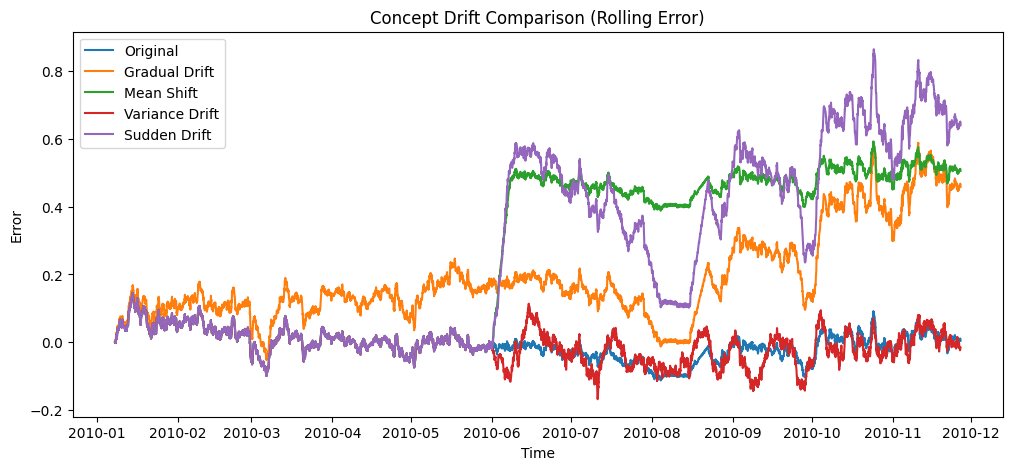

In [22]:
plt.figure(figsize=(12,5))

plt.plot(
    (y_test - preds).rolling(168).mean(),
    label='Original'
)

plt.plot(
    (y_gradual - preds).rolling(168).mean(),
    label='Gradual Drift'
)

plt.plot(
    (y_mean_shift - preds).rolling(168).mean(),
    label='Mean Shift'
)

plt.plot(
    (y_variance - preds).rolling(168).mean(),
    label='Variance Drift'
)

plt.plot(
    (y_sudden - preds).rolling(168).mean(),
    label='Sudden Drift'
)

plt.legend()
plt.title("Concept Drift Comparison (Rolling Error)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

In [23]:
# after adding drift
print("\n===== GRADUAL DRIFT =====")
drift_report(model, X_train, y_train, X_test, y_gradual)

print("\n===== MEAN SHIFT DRIFT =====")
drift_report(model, X_train, y_train, X_test, y_mean_shift)

print("\n===== VARIANCE DRIFT =====")
drift_report(model, X_train, y_train, X_test, y_variance)

print("\n===== SUDDEN DRIFT =====")
drift_report(model, X_train, y_train, X_test, y_sudden)


===== GRADUAL DRIFT =====
Current 7-Day MAE: 0.568 (Threshold: 0.519)
 Performance Drift Detected

Current 14-Day Avg: 1.598 kW (Train Avg: 1.097)
 Data Drift Detected
Std Ratio: 1.28
 Variance Stable

===== MEAN SHIFT DRIFT =====
Current 7-Day MAE: 0.536 (Threshold: 0.519)
 Performance Drift Detected

Current 14-Day Avg: 1.645 kW (Train Avg: 1.097)
 Data Drift Detected
Std Ratio: 0.92
 Variance Stable

===== VARIANCE DRIFT =====
Current 7-Day MAE: 0.525 (Threshold: 0.519)
 Performance Drift Detected

Current 14-Day Avg: 1.125 kW (Train Avg: 1.097)
 Data Stable
Std Ratio: 1.04
 Variance Stable

===== SUDDEN DRIFT =====
Current 7-Day MAE: 0.710 (Threshold: 0.519)
 Performance Drift Detected

Current 14-Day Avg: 1.780 kW (Train Avg: 1.097)
 Data Drift Detected
Std Ratio: 1.43
 Variance Drift Detected


# XGBoost

In [24]:
df = pd.read_csv("cleaned_data.csv")
df = df.drop([
    'Global_reactive_power','Voltage','Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3'], axis=1)
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)
df = df.sort_index()
df.columns
# Train-test split
train = df.loc[:'2009-12-31']
test = df.loc['2010-01-01':]

y_train = train['Global_active_power']
y_test = test['Global_active_power']

X_train = train.drop('Global_active_power', axis=1)
X_test = test.drop('Global_active_power', axis=1)
print("size of X_train:", X_train.shape, "size of y_train:", y_train.shape)
print("size of X_test:", X_test.shape, "size of y_test:", y_test.shape)

size of X_train: (26623, 9) size of y_train: (26623,)
size of X_test: (7918, 9) size of y_test: (7918,)


In [25]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_xgb = mean_absolute_error(y_test, xgb_preds)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_preds))

print(mae_xgb, rmse_xgb)

0.333466493248887 0.4820946875754596


In [27]:
xgb_residuals = y_test - xgb_preds

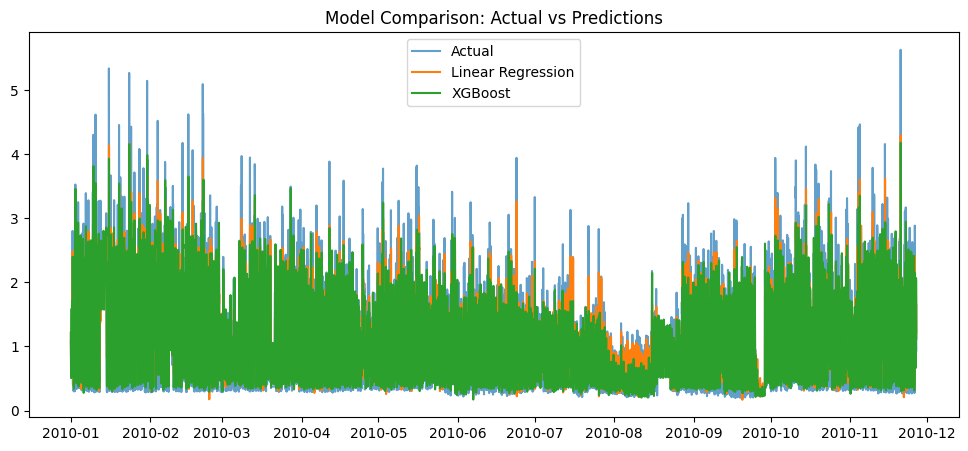

In [28]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label='Actual', alpha=0.7)
plt.plot(y_test.index, preds, label='Linear Regression')
plt.plot(y_test.index, xgb_preds, label='XGBoost')

plt.legend()
plt.title("Model Comparison: Actual vs Predictions")
plt.show()

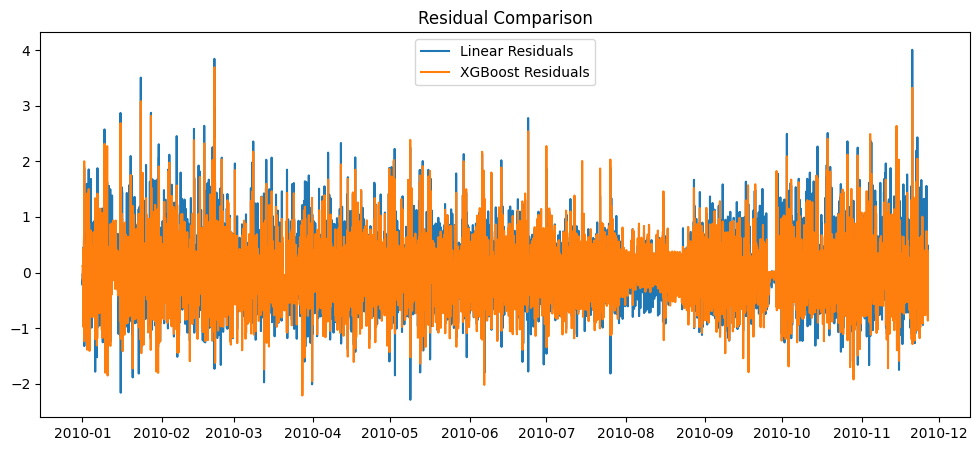

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, residuals, label='Linear Residuals')
plt.plot(y_test.index, xgb_residuals, label='XGBoost Residuals')

plt.legend()
plt.title("Residual Comparison")
plt.show()

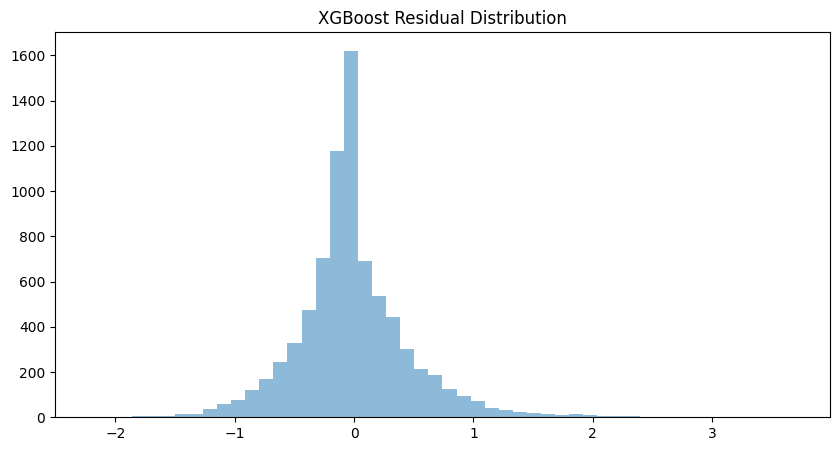

In [30]:
plt.figure(figsize=(10,5))
plt.hist(xgb_residuals, bins=50, alpha=0.5)
plt.title("XGBoost Residual Distribution")
plt.show()

In [31]:
print(xgb_residuals.describe())

count    7918.000000
mean       -0.017376
std         0.481812
min        -2.211487
25%        -0.249484
50%        -0.053458
75%         0.186338
max         3.692206
Name: Global_active_power, dtype: float64


In [32]:
# percentile based anomalies
train_xgb_preds = xgb_model.predict(X_train)
train_xgb_residuals = y_train - train_xgb_preds

xgb_upper_anomaly_threshold = train_xgb_residuals.quantile(0.99)
xgb_lower_anomaly_threshold = train_xgb_residuals.quantile(0.01)
xgb_anomalies = (xgb_residuals > xgb_upper_anomaly_threshold) | (xgb_residuals < xgb_lower_anomaly_threshold)
print("Total anomalies detected (percentile):", xgb_anomalies.sum())

Total anomalies detected (percentile): 201


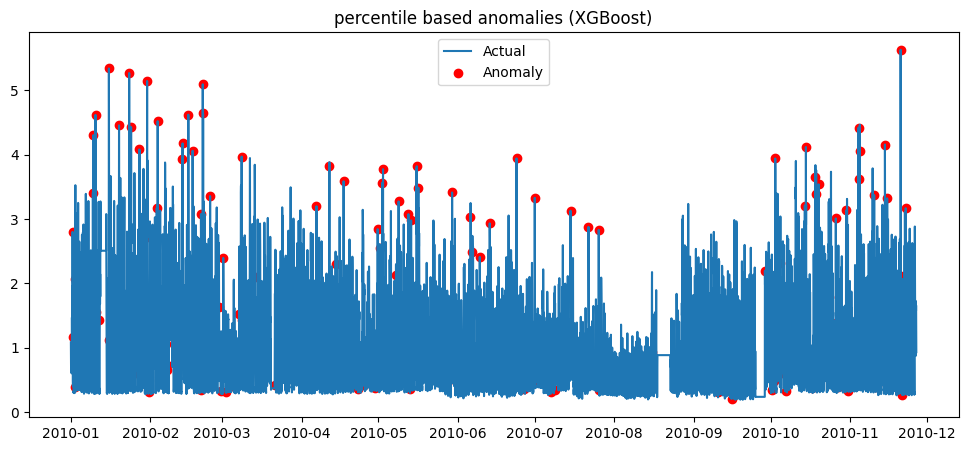

In [58]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual')

plt.scatter(
    y_test.index[xgb_anomalies],
    y_test[xgb_anomalies],
    color='red',
    label='Anomaly'
)
plt.title("percentile based anomalies (XGBoost)")

plt.legend()
plt.show()

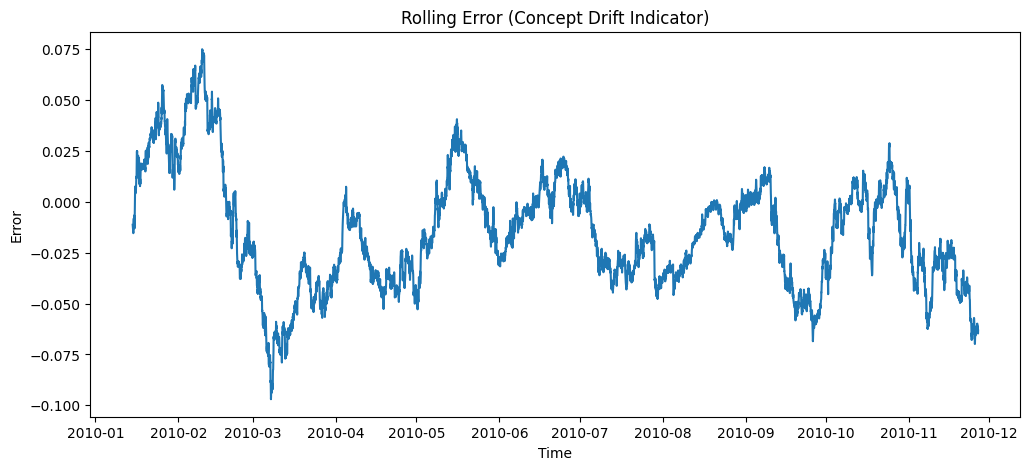

In [34]:
# Concept Drift (2 Weeks)
xgb_rolling_error = xgb_residuals.rolling(336).mean()
plt.figure(figsize=(12,5))
plt.plot(xgb_rolling_error)
plt.title("Rolling Error (Concept Drift Indicator)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

In [35]:
# Drift Monitoring for XGBoost
# Before drift
drift_report(xgb_model, X_train, y_train, X_test, y_test)


print("\n===== GRADUAL DRIFT =====")
drift_report(xgb_model, X_train, y_train, X_test, y_gradual)

print("\n===== MEAN SHIFT DRIFT =====")
drift_report(xgb_model, X_train, y_train, X_test, y_mean_shift)

print("\n===== VARIANCE DRIFT =====")
drift_report(xgb_model, X_train, y_train, X_test, y_variance)

print("\n===== SUDDEN DRIFT =====")
drift_report(xgb_model, X_train, y_train, X_test, y_sudden)

Current 7-Day MAE: 0.297 (Threshold: 0.389)
 Performance Stable

Current 14-Day Avg: 1.145 kW (Train Avg: 1.097)
 Data Stable
Std Ratio: 0.92
 Variance Stable

===== GRADUAL DRIFT =====
Current 7-Day MAE: 0.473 (Threshold: 0.389)
 Performance Drift Detected

Current 14-Day Avg: 1.598 kW (Train Avg: 1.097)
 Data Drift Detected
Std Ratio: 1.28
 Variance Stable

===== MEAN SHIFT DRIFT =====
Current 7-Day MAE: 0.493 (Threshold: 0.389)
 Performance Drift Detected

Current 14-Day Avg: 1.645 kW (Train Avg: 1.097)
 Data Drift Detected
Std Ratio: 0.92
 Variance Stable

===== VARIANCE DRIFT =====
Current 7-Day MAE: 0.435 (Threshold: 0.389)
 Performance Drift Detected

Current 14-Day Avg: 1.125 kW (Train Avg: 1.097)
 Data Stable
Std Ratio: 1.04
 Variance Stable

===== SUDDEN DRIFT =====
Current 7-Day MAE: 0.604 (Threshold: 0.389)
 Performance Drift Detected

Current 14-Day Avg: 1.780 kW (Train Avg: 1.097)
 Data Drift Detected
Std Ratio: 1.43
 Variance Drift Detected


# ARIMAX

In [3]:
df = pd.read_csv("cleaned_data.csv")
df = df.drop([
    'Global_reactive_power','Voltage','Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3'], axis=1)
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)
df = df.sort_index()
df.columns

Index(['Global_active_power', 'hour', 'day', 'month', 'weekday', 'lag_1',
       'lag_2', 'lag_24', 'rolling_mean_3', 'rolling_mean_24'],
      dtype='object')

In [4]:
# 1. Cyclical Encoding for 'hour' (Cycle length = 24)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# 2. Cyclical Encoding for 'weekday' (Cycle length = 7)
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

# (Optional) If you are using 'month', the cycle is 12
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# 3. Drop the original linear time columns to avoid confusing the model
df = df.drop(['hour', 'weekday', 'month'], axis=1)

In [5]:
# Train-test split
train = df.loc[:'2009-12-31']
test = df.loc['2010-01-01':]

y_train = train['Global_active_power']
y_test = test['Global_active_power']

X_train = train.drop('Global_active_power', axis=1)
X_test = test.drop('Global_active_power', axis=1)
print("size of X_train:", X_train.shape, "size of y_train:", y_train.shape)
print("size of X_test:", X_test.shape, "size of y_test:", y_test.shape)

size of X_train: (26623, 12) size of y_train: (26623,)
size of X_test: (7918, 12) size of y_test: (7918,)


In [6]:
# 1. Define your exogenous features (only the cyclical time features)
exog_features = ['hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos']

X_train_exog = X_train[exog_features]
X_test_exog = X_test[exog_features]

In [ ]:
import pmdarima as pm

print("Fitting ARIMAX model... This may take a few minutes.")

# 1. Fit the model
# We set seasonal=False here because we are using our cyclical features 
# to handle the seasonality for us (saving massive computation time).
arima_model = pm.auto_arima(
    y=y_train,
    X=X_train_exog,
    seasonal=True,
    m=24,
    max_p=2, max_q=2,      # keep it constrained so it doesn't take forever
    max_P=1, max_Q=1,      # seasonal orders
    stepwise=True,
    suppress_warnings=True
)

print(arima_model.summary())

# 2. Generate Predictions
arima_preds = arima_model.predict(n_periods=len(y_test), X=X_test_exog)

# 3. Calculate Residuals 
arima_residuals = y_test - arima_preds

Fitting ARIMAX model... This may take a few minutes.


c:\Users\sabar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\sabar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\sabar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\sabar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\sabar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\d

In [ ]:
# 1. Calculate ARIMAX Metrics
arima_mae = mean_absolute_error(y_test, arima_preds)
arima_rmse = np.sqrt(mean_squared_error(y_test, arima_preds))

print(f"ARIMAX MAE: {arima_mae:.3f}")
print(f"ARIMAX RMSE: {arima_rmse:.3f}")

ARIMAX MAE: 1.077
ARIMAX RMSE: 1.221


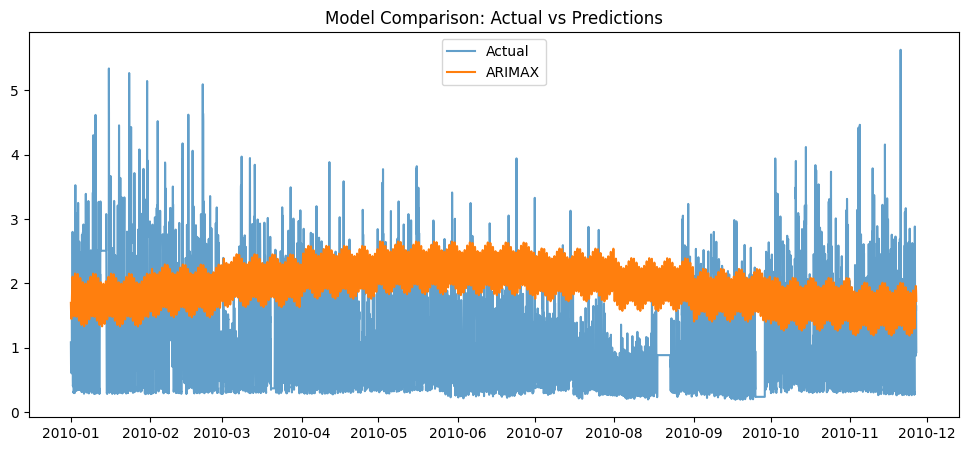

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label='Actual', alpha=0.7)
plt.plot(y_test.index, arima_preds, label='ARIMAX')
plt.legend()
plt.title("Model Comparison: Actual vs Predictions")
plt.show()

In [ ]:
# percentile based anomalies
train_arima_preds = arima_model.predict_in_sample(X=X_train_exog)
train_arima_residuals = y_train - train_arima_preds

arima_upper_anomaly_threshold = train_arima_residuals.quantile(0.99)
arima_lower_anomaly_threshold = train_arima_residuals.quantile(0.01)
arima_anomalies = (arima_residuals > arima_upper_anomaly_threshold) | (arima_residuals < arima_lower_anomaly_threshold)
print("Total anomalies detected (percentile):", arima_anomalies.sum())

Total anomalies detected (percentile): 2961


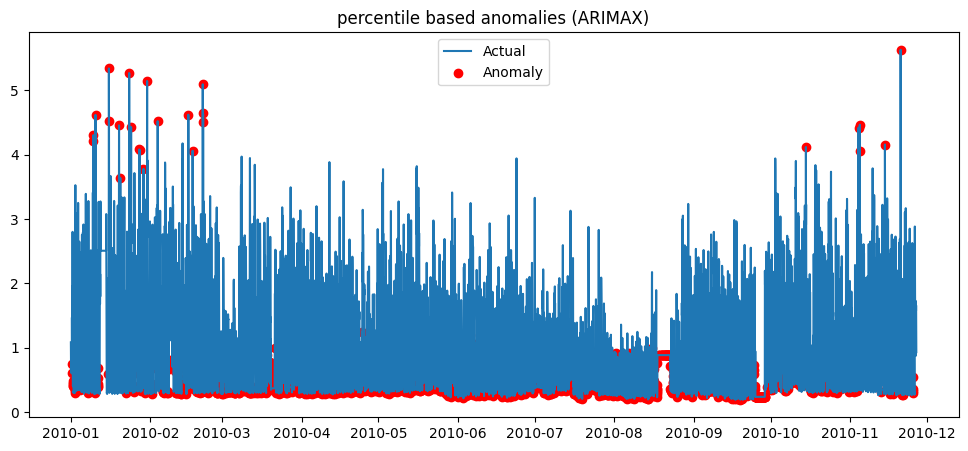

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual')

plt.scatter(
    y_test.index[arima_anomalies],
    y_test[arima_anomalies],
    color='red',
    label='Anomaly'
)
plt.title("percentile based anomalies (ARIMAX)")

plt.legend()
plt.show()

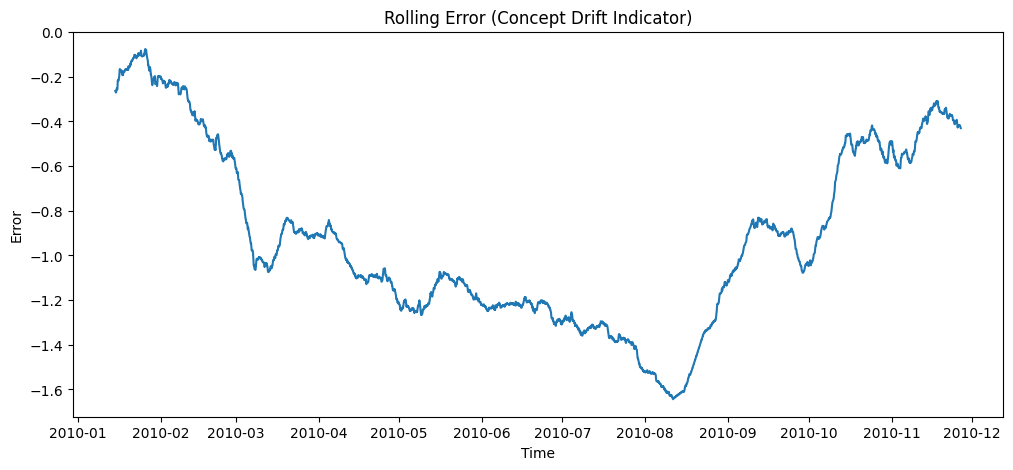

In [ ]:
# Concept Drift (2 Weeks)
arima_rolling_error = arima_residuals.rolling(336).mean()
plt.figure(figsize=(12,5))
plt.plot(arima_rolling_error)
plt.title("Rolling Error (Concept Drift Indicator)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

In [ ]:
# Drift Monitoring for ARIMA
# Before drift
drift_report(arima_model, X_train_exog, y_train, X_test_exog, y_test)


print("\n===== GRADUAL DRIFT =====")
drift_report(arima_model, X_train_exog, y_train, X_test_exog, y_gradual)

print("\n===== MEAN SHIFT DRIFT =====")
drift_report(arima_model, X_train_exog, y_train, X_test_exog, y_mean_shift)

print("\n===== VARIANCE DRIFT =====")
drift_report(arima_model, X_train_exog, y_train, X_test_exog, y_variance)

print("\n===== SUDDEN DRIFT =====")
drift_report(arima_model, X_train_exog, y_train, X_test_exog, y_sudden)

c:\Users\sabar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\sabar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Current 7-Day MAE: 0.666 (Threshold: 0.533)
 Performance Drift Detected

Current 14-Day Avg: 1.145 kW (Train Avg: 1.097)
 Data Stable
Std Ratio: 0.92
 Variance Stable

===== GRADUAL DRIFT =====
Current 7-Day MAE: 0.746 (Threshold: 0.533)
 Performance Drift Detected

Current 14-Day Avg: 1.598 kW (Train Avg: 1.097)
 Data Drift Detected
Std Ratio: 1.28
 Variance Stable

===== MEAN SHIFT DRIFT =====


c:\Users\sabar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\sabar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Current 7-Day MAE: 0.519 (Threshold: 0.533)
 Performance Stable

Current 14-Day Avg: 1.645 kW (Train Avg: 1.097)
 Data Drift Detected
Std Ratio: 0.92
 Variance Stable

===== VARIANCE DRIFT =====
Current 7-Day MAE: 0.778 (Threshold: 0.533)
 Performance Drift Detected

Current 14-Day Avg: 1.125 kW (Train Avg: 1.097)
 Data Stable
Std Ratio: 1.04
 Variance Stable

===== SUDDEN DRIFT =====
Current 7-Day MAE: 0.843 (Threshold: 0.533)
 Performance Drift Detected

Current 14-Day Avg: 1.780 kW (Train Avg: 1.097)
 Data Drift Detected
Std Ratio: 1.43
 Variance Drift Detected


c:\Users\sabar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## IMP PLOTS

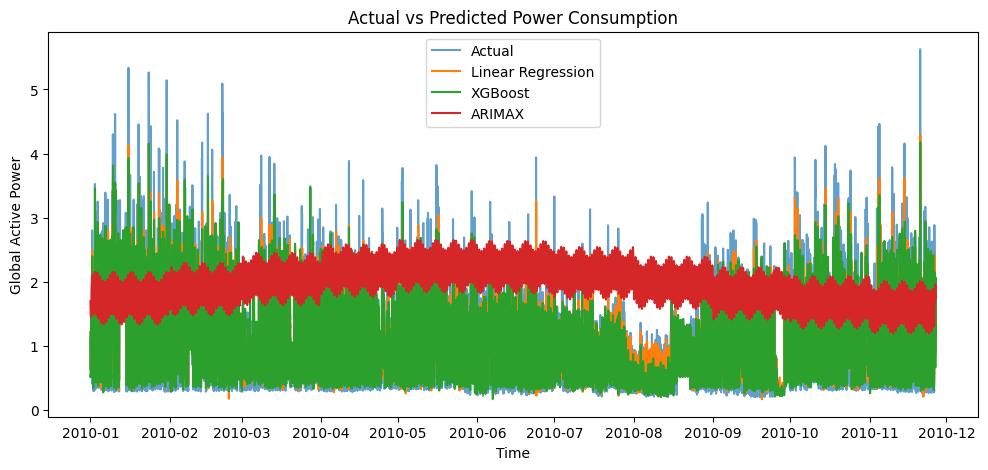

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label='Actual', alpha=0.7)
plt.plot(y_test.index, preds, label='Linear Regression')
plt.plot(y_test.index, xgb_preds, label='XGBoost')
plt.plot(y_test.index, arima_preds, label='ARIMAX')

plt.title("Actual vs Predicted Power Consumption")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.legend()
plt.show()


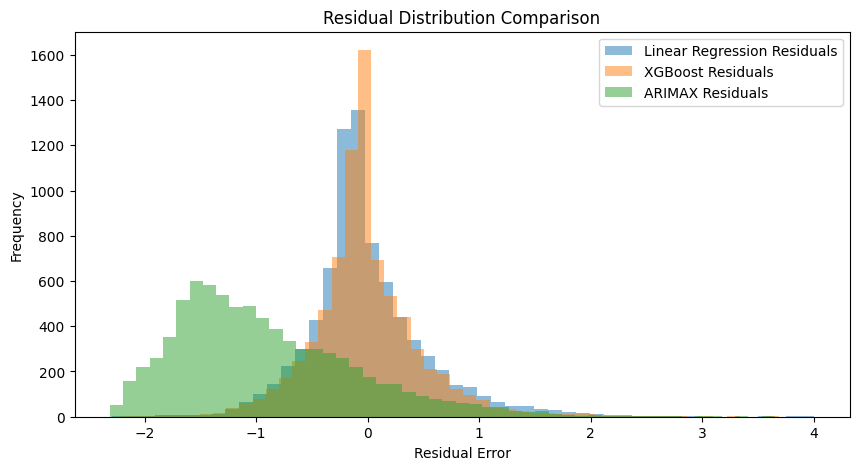

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(residuals, bins=50, alpha=0.5, label='Linear Regression Residuals')
plt.hist(xgb_residuals, bins=50, alpha=0.5, label='XGBoost Residuals')
plt.hist(arima_residuals, bins=50, alpha=0.5, label='ARIMAX Residuals')
plt.title("Residual Distribution Comparison")
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.legend()
plt.show()

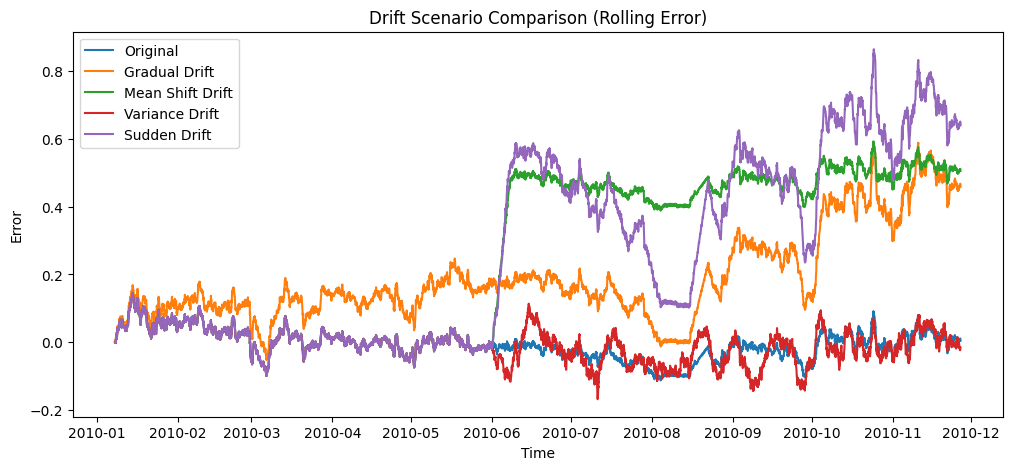

In [ ]:
plt.figure(figsize=(12,5))

plt.plot((y_test - preds).rolling(168).mean(), label='Original')

plt.plot((y_gradual - preds).rolling(168).mean(), label='Gradual Drift')
plt.plot((y_mean_shift - preds).rolling(168).mean(), label='Mean Shift Drift')
plt.plot((y_variance - preds).rolling(168).mean(), label='Variance Drift')
plt.plot((y_sudden - preds).rolling(168).mean(), label='Sudden Drift')

plt.title("Drift Scenario Comparison (Rolling Error)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.legend()
plt.show()

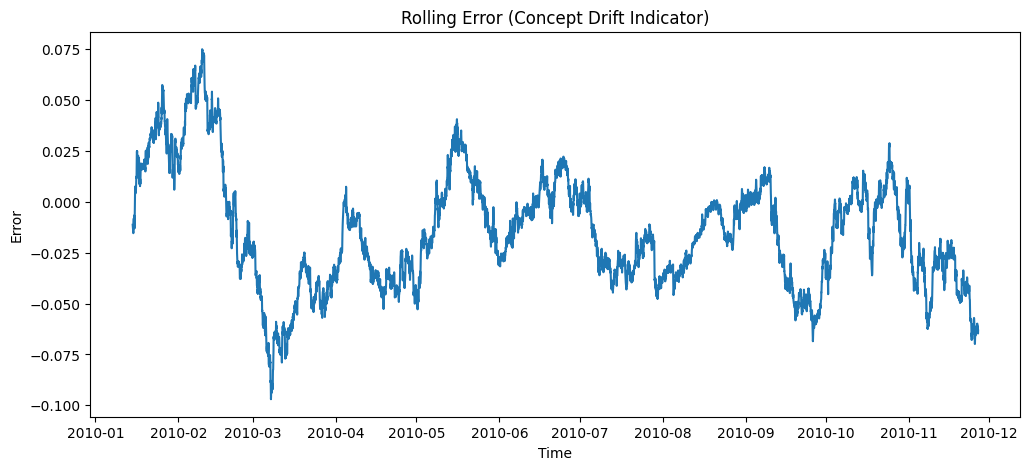

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(xgb_rolling_error)
plt.title("Rolling Error (Concept Drift Indicator)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

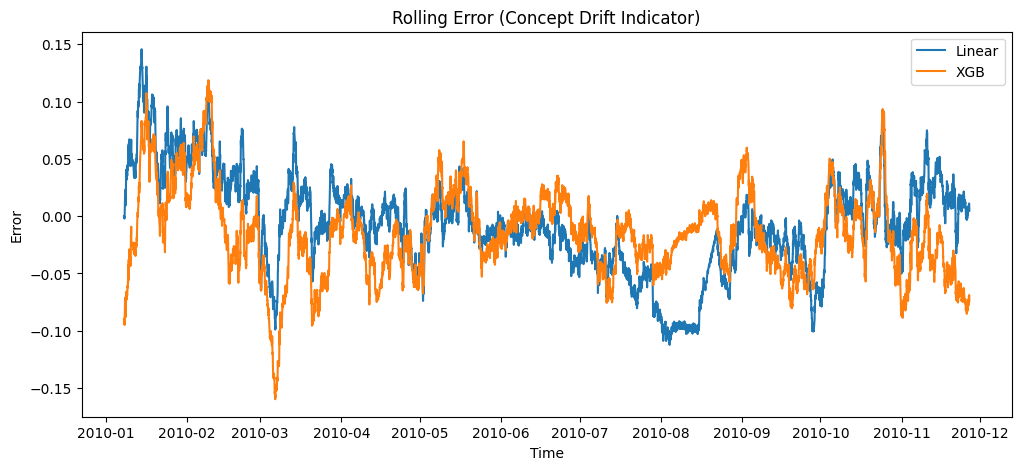

In [ ]:
# Concept Drift (1 Weeks)
linear_rolling_error = residuals.rolling(168).mean()
xgb_rolling_error = xgb_residuals.rolling(168).mean()
plt.figure(figsize=(12,5))
plt.plot(linear_rolling_error, label="Linear")
plt.plot(xgb_rolling_error, label="XGB")
plt.title("Rolling Error (Concept Drift Indicator)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.legend()
plt.show()

In [ ]:
print("Linear Residuals:")
print(residuals.describe())
print("\nXGBoost Residuals:")
print(xgb_residuals.describe())
print("\nARIMAX Residuals:")
print(arima_residuals.describe())

Linear Residuals:
count    7918.000000
mean       -0.006255
std         0.537779
min        -2.288005
25%        -0.277873
50%        -0.090660
75%         0.216481
max         4.006162
Name: Global_active_power, dtype: float64

XGBoost Residuals:
count    7918.000000
mean       -0.017376
std         0.481812
min        -2.211487
25%        -0.249484
50%        -0.053458
75%         0.186338
max         3.692206
Name: Global_active_power, dtype: float64

ARIMAX Residuals:
count    7918.000000
mean       -0.907912
std         0.816448
min        -2.311780
25%        -1.512096
50%        -1.064419
75%        -0.438759
max         3.653095
dtype: float64


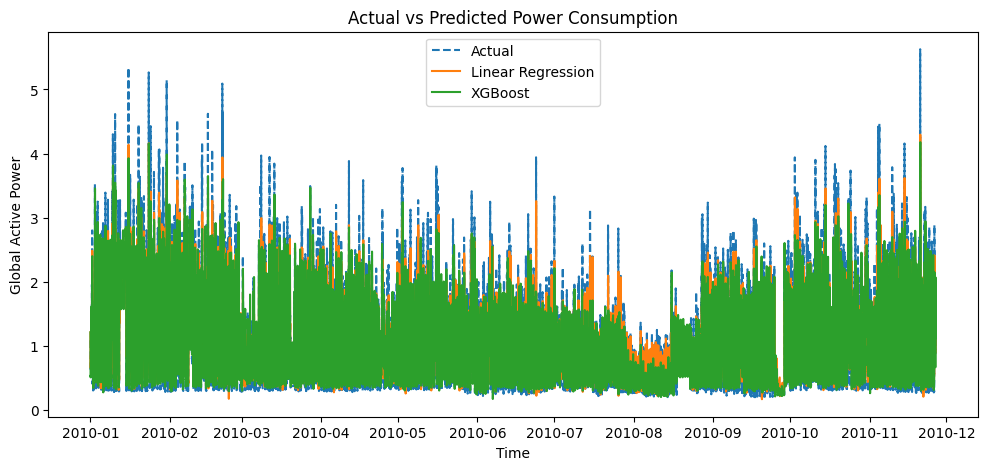

In [ ]:
# model wise prediction curve
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual',linestyle='--')
plt.plot(y_test.index, preds, label='Linear Regression', linestyle='-')
plt.plot(y_test.index, xgb_preds, label='XGBoost', linestyle='-')
plt.title("Actual vs Predicted Power Consumption")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.legend()
plt.show()

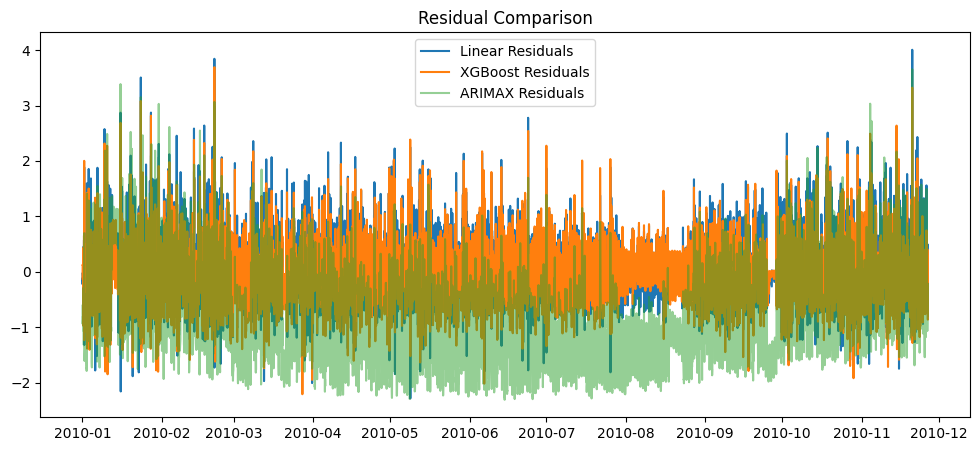

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, residuals, label='Linear Residuals')
plt.plot(y_test.index, xgb_residuals, label='XGBoost Residuals')
plt.plot(y_test.index, arima_residuals, label='ARIMAX Residuals',alpha=0.5)
plt.legend()
plt.title("Residual Comparison")
plt.show()

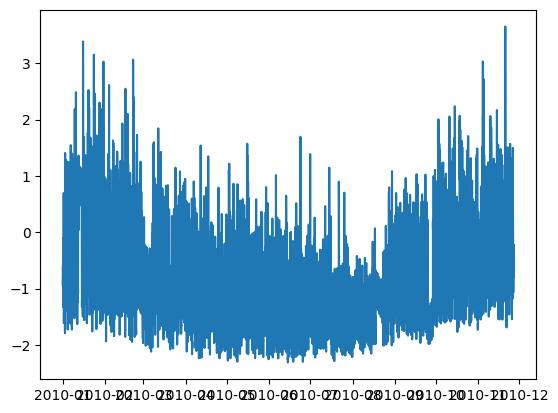

In [ ]:
plt.plot(y_test.index, arima_residuals, label='ARIMAX Residuals')